#Smart Student Monitoring System

#Data Understading

In [79]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = '/content/drive/MyDrive/global_student_digital_behavior_dataset.csv'
data = pd.read_csv(path, index_col='student_id')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
arab_countries = [ "Jordan", "Saudi Arabia", "United Arab Emirates", "Qatar", "Kuwait", "Bahrain", "Oman",
    "Egypt", "Iraq", "Syria", "Lebanon", "Palestine", "Yemen",
    "Morocco", "Algeria", "Tunisia", "Libya", "Sudan", "Mauritania", "Somalia", "Djibouti", "Comoros","UAE","KSA"]

data = data[data['country'].isin(arab_countries)]

In [81]:
data.head()

,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,device_access,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
student_id,,,,,,,,,,,,,,,,,,,,,
1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,Smartphone,...,38.699484,3.119569,3.681066,79.508194,No,No,8.179932,66.662166,0.0,26.516722
7,Saudi Arabia,Developing,18.41,63.70,33.33,18,Male,Rural,Low,Smartphone,...,116.460859,15.399315,6.062651,36.552800,No,No,12.804566,64.471782,0.0,64.286132
9,Saudi Arabia,Developing,18.41,63.70,33.33,16,Female,Rural,Middle,Smartphone,...,115.897080,14.026891,7.117822,67.915944,No,No,9.090297,53.904756,0.0,45.826369
16,Kuwait,Developing,33.98,46.91,40.26,19,Male,Rural,Low,Smartphone,...,90.228265,13.794961,4.604069,51.036190,No,No,7.596000,56.737892,0.0,48.111064
22,Qatar,Developing,16.30,54.93,27.19,20,Male,Rural,Middle,Smartphone,...,83.328069,18.164738,6.335929,68.132269,No,Yes,14.773921,47.139911,0.0,40.568421


In [82]:
print("Number of Rows",len(data), "Number of Columns",len(data.columns))

Number of Rows 59611 Number of Columns 47


#Data Cleansing

In [83]:
data.duplicated().value_counts()

,count
False,59611


In [84]:
data.isnull().sum().sum()

np.int64(30776)

In [85]:
data.isnull().sum()

,0
country,0
development_level,0
poverty_rate_percent,0
internet_infrastructure_index,0
average_internet_speed_mbps,0
age,0
gender,0
urban_rural,0
family_income_level,0
device_access,0


In [86]:
data['field_of_study']=data['field_of_study'].fillna(data['field_of_study'].mode()[0])
data['brain_rot_level']=data['brain_rot_level'].fillna(data['brain_rot_level'].mode()[0])

In [87]:
data.isnull().sum().sum()

np.int64(0)

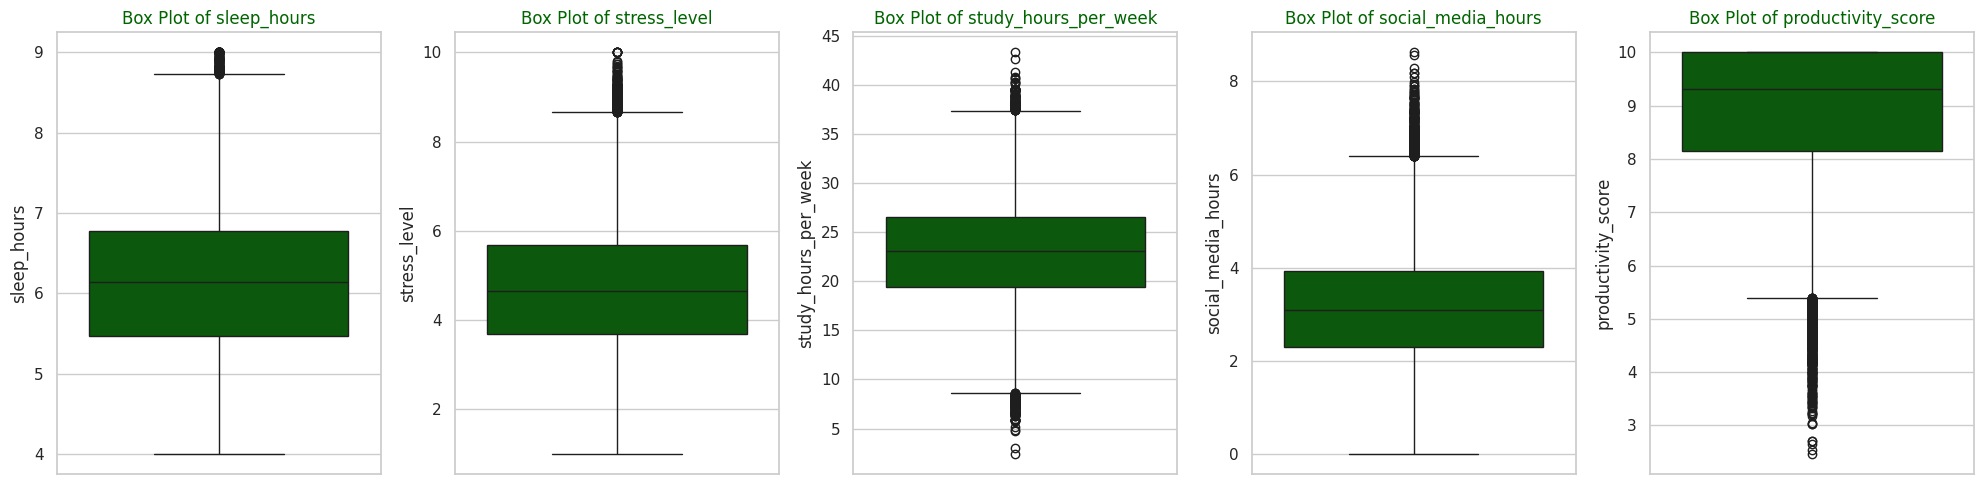

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'sleep_hours',
    'stress_level',
    'study_hours_per_week',
    'social_media_hours',
    'productivity_score'
]

# Set style
sns.set(style="whitegrid")

# Create subplot grid: 1 row, 5 columns
plt.figure(figsize=(20, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i + 1)

    sns.boxplot(
        y=data[col],
        color='darkgreen'
    )

    plt.title(f'Box Plot of {col}', color='darkgreen')

plt.tight_layout()
plt.show()

In [89]:
num_cols = [
    'study_hours_per_week',
    'sleep_hours',
    'internet_access_hours',
    'social_media_hours',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'attention_span_minutes',
    'productivity_score',
    'academic_motivation',
    'wellbeing_index',
    'age',
    'sessions_per_day',
    'brain_rot_index',
]

# ensure numeric (important)
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    # skip if column has no variation
    if IQR == 0:
        continue

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # replace outliers with median (NOT 0)
    median = data[col].median()

    data.loc[data[col] < lower, col] = median
    data.loc[data[col] > upper, col] = median


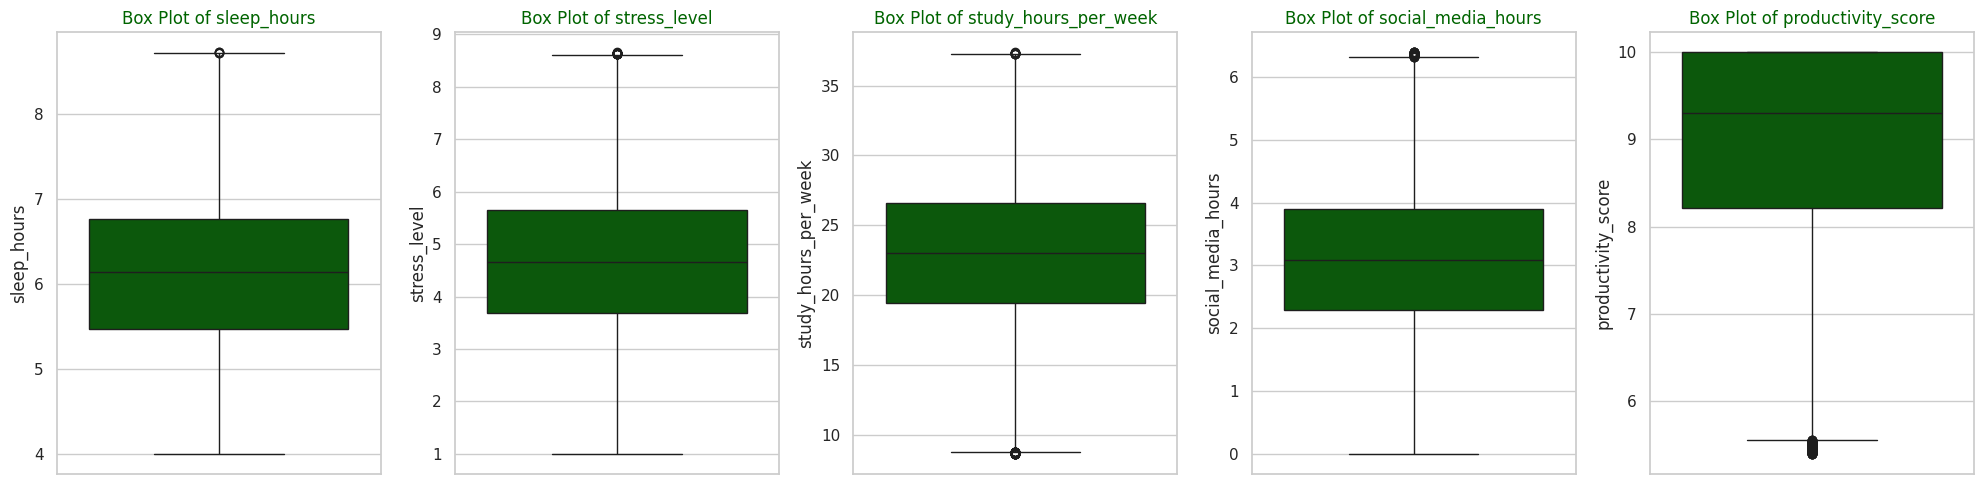

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'sleep_hours',
    'stress_level',
    'study_hours_per_week',
    'social_media_hours',
    'productivity_score'
]

# Set style
sns.set(style="whitegrid")

# Create subplot grid: 1 row, 5 columns
plt.figure(figsize=(20, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i + 1)

    sns.boxplot(
        y=data[col],
        color='darkgreen'
    )

    plt.title(f'Box Plot of {col}', color='darkgreen')

plt.tight_layout()
plt.show()

# Discriptive Statistics

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59611 entries, 1 to 499991
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         59611 non-null  object 
 1   development_level               59611 non-null  object 
 2   poverty_rate_percent            59611 non-null  float64
 3   internet_infrastructure_index   59611 non-null  float64
 4   average_internet_speed_mbps     59611 non-null  float64
 5   age                             59611 non-null  int64  
 6   gender                          59611 non-null  object 
 7   urban_rural                     59611 non-null  object 
 8   family_income_level             59611 non-null  object 
 9   device_access                   59611 non-null  object 
 10  internet_access_hours           59611 non-null  float64
 11  education_level                 59611 non-null  object 
 12  field_of_study                  5961

In [92]:
data.describe()

,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,internet_access_hours,academic_motivation,online_learning_hours,social_media_hours,sessions_per_day,average_session_length_minutes,...,anxiety_score,depression_score,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
count,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,...,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000,59611.000000
mean,30.206973,51.928774,38.015803,19.994598,4.611468,5.357665,6.123131,3.109902,9.273108,36.366506,...,4.677008,4.865955,91.376102,11.966900,5.287169,55.877455,13.194780,58.473328,0.089888,40.787950
std,11.705567,15.818699,21.150894,3.155624,1.388368,1.749153,1.819155,1.182648,3.122742,12.856598,...,1.707058,2.029070,31.555910,4.276964,1.534174,26.273388,5.692863,10.135520,0.710557,13.543785
min,16.300000,20.760000,6.030000,15.000000,0.758413,1.000000,0.000000,0.000000,1.000000,3.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,30.272379,0.000000,0.000000
25%,18.410000,46.910000,27.190000,17.000000,3.678285,4.189564,4.900020,2.290053,7.115149,27.549766,...,3.488189,3.421484,69.685856,9.046417,4.234140,36.566612,9.267492,51.587754,0.000000,31.343850
50%,27.150000,54.930000,33.330000,20.000000,4.653798,5.419984,6.155254,3.085984,9.215109,35.918589,...,4.669055,4.813759,90.257958,11.867552,5.254912,51.865774,12.752592,58.568556,0.000000,40.158864
75%,34.310000,63.700000,45.040000,23.000000,5.570040,6.595587,7.379791,3.901475,11.373758,44.705413,...,5.844979,6.241118,111.974935,14.778199,6.306857,71.199608,16.842591,65.567740,0.000000,49.473102
max,51.400000,70.890000,76.570000,25.000000,8.463121,10.000000,12.920552,6.390363,17.910027,90.000000,...,9.438295,10.000000,238.596636,33.165476,10.000000,179.177715,35.604855,86.695448,17.083668,97.433197


In [93]:
data.describe(include='object')

,country,development_level,gender,urban_rural,family_income_level,device_access,education_level,field_of_study,late_night_usage,brain_rot_level,cyberbullying_exposure,adult_content_exposure
count,59611,59611,59611,59611,59611,59611,59611,59611,59611,59611,59611,59611
unique,6,2,3,2,3,4,6,6,4,2,2,2
top,Saudi Arabia,Developing,Male,Urban,Middle,Smartphone,School,Law,Sometimes,Low,No,No
freq,10105,49734,29529,30719,28287,38244,22176,34858,27365,54025,52528,49216


In [94]:
num_cols = [
    'study_hours_per_week',
    'sleep_hours',
    'internet_access_hours',
    'social_media_hours',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'attention_span_minutes',
    'productivity_score',
    'wellbeing_index'
]

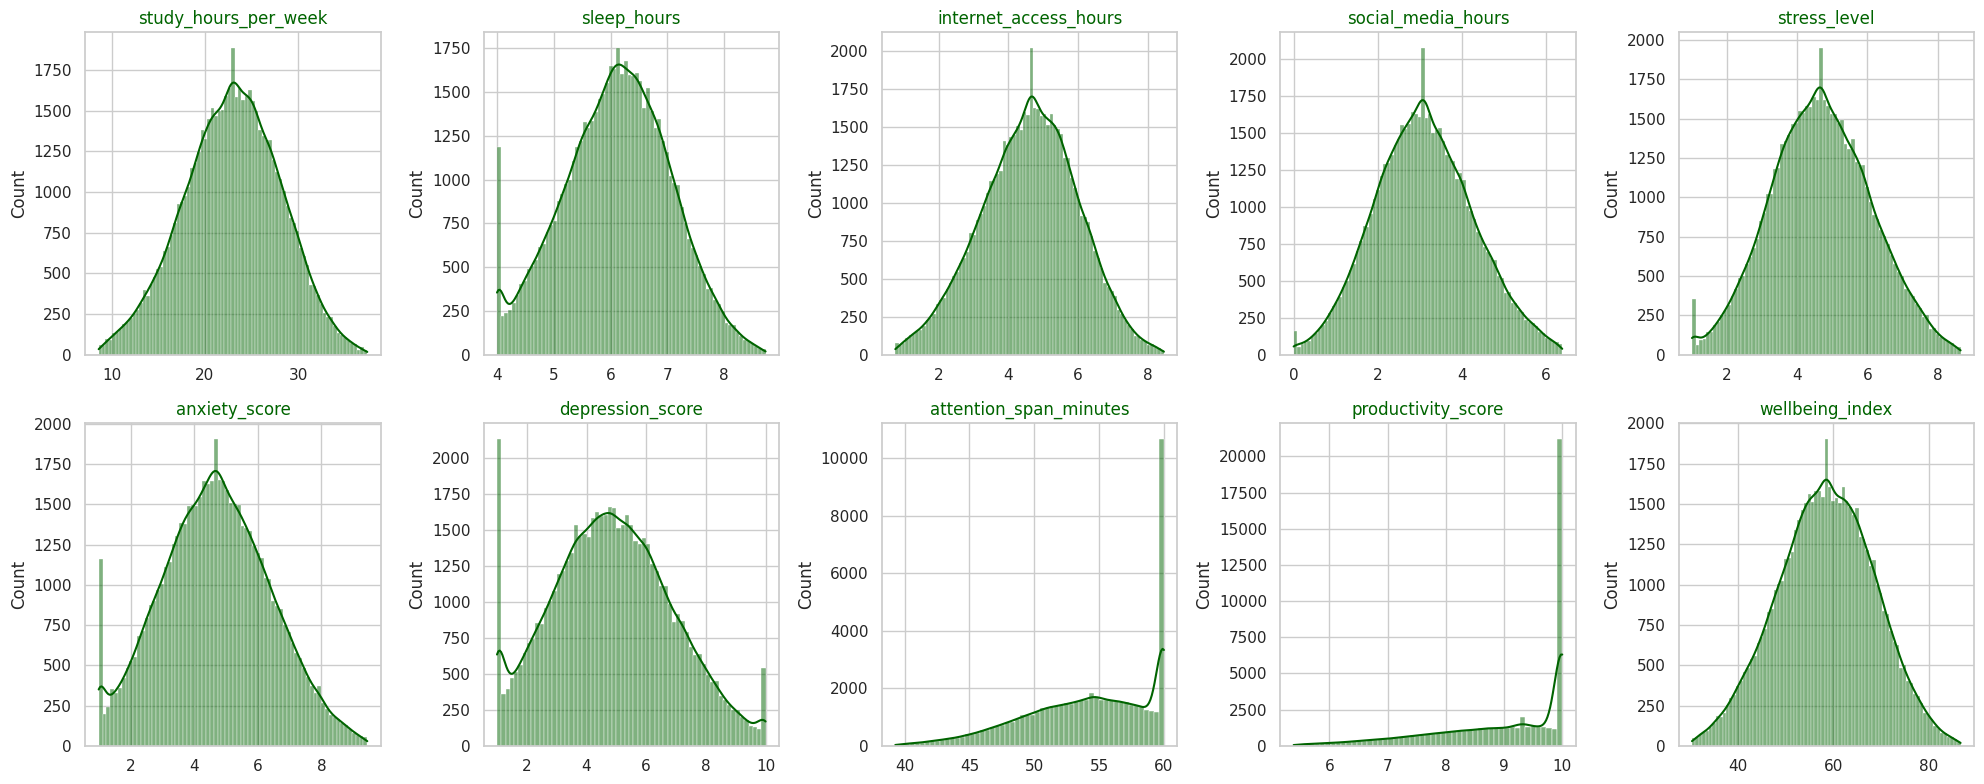

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data[col],
        kde=True,
        ax=axes[i],
        color='darkgreen'
    )

    axes[i].set_title(f'{col}', color='darkgreen')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [95]:
bins = [0, 10, 20, 30, 40, 60]

labels = [
    '0-10 (Very Low)',
    '10-20 (Low)',
    '20-30 (Moderate)',
    '30-40 (High)',
    '40+ (Very High)'
]

data['study_hours_group'] = pd.cut(
    data['study_hours_per_week'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [96]:
pivot1 = pd.pivot_table(
    data,
    values='academic_risk_score',
    index='study_hours_group',
    aggfunc='mean'
)

pivot1

/tmp/ipykernel_823/1625930452.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = pd.pivot_table(


,academic_risk_score
study_hours_group,
0-10 (Very Low),1.349409
10-20 (Low),0.233298
20-30 (Moderate),0.028715
30-40 (High),0.000265


In [97]:
bins = [0, 4, 6, 8, 10, 24]

labels = [
    '0-4 (Very Low)',
    '4-6 (Low)',
    '6-8 (Normal)',
    '8-10 (High)',
    '10+ (Very High)'
]

data['sleep_group'] = pd.cut(
    data['sleep_hours'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [98]:
pivot2 = pd.pivot_table(
    data,
    values=('stress_level','anxiety_score','depression_score'),
    index='sleep_group',
    aggfunc='mean'
)

pivot2

/tmp/ipykernel_823/2557924055.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = pd.pivot_table(


,anxiety_score,depression_score,stress_level
sleep_group,,,
0-4 (Very Low),6.713423,7.628208,6.708471
4-6 (Low),5.492115,5.819607,5.512215
6-8 (Normal),4.043283,4.108512,4.027824
8-10 (High),2.682700,2.646638,2.590310


In [99]:
bins = [0, 2, 4, 6, 8, 24]

labels = [
    '0-2 (Very Low)',
    '2-4 (Low)',
    '4-6 (Moderate)',
    '6-8 (High)',
    '8+ (Very High)'
]

data['social_media_group'] = pd.cut(
    data['social_media_hours'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [100]:
pivot3 = pd.pivot_table(
    data,
    values=('academic_risk_score','stress_level'),
    index='social_media_group',
    aggfunc='mean'
)

pivot3

/tmp/ipykernel_823/3408330602.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot3 = pd.pivot_table(


,academic_risk_score,stress_level
social_media_group,,
0-2 (Very Low),0.004706,3.502553
2-4 (Low),0.039097,4.554897
4-6 (Moderate),0.280129,5.886740
6-8 (High),0.601114,6.513137


In [101]:
bins = [15, 17, 21, 25]

labels = [
    '15-17',
    '17-21',
    '21-25'
]

data['age_group'] = pd.cut(
    data['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [102]:
pivot5 = pd.pivot_table(
    data,
    values=('financial_risk_score','academic_risk_score','productivity_score'),
    index='cyberbullying_exposure',
    aggfunc='mean'
)

pivot5

,academic_risk_score,financial_risk_score,productivity_score
cyberbullying_exposure,,,
No,0.085122,40.509010,8.984422
Yes,0.125229,42.856585,8.812362


In [103]:
bins = [0, 3, 6, 8, 10]

labels = [
    '0-3 (Very Low)',
    '3-6 (Low)',
    '6-8 (Medium)',
    '8-10 (High)'
]

data['motivation_group'] = pd.cut(
    data['academic_motivation'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [104]:
pivot6 = pd.pivot_table(
    data,
    values=('academic_risk_score','productivity_score'),
    index='motivation_group',
    aggfunc='mean'
)

pivot6

/tmp/ipykernel_823/1483924154.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot6 = pd.pivot_table(


,academic_risk_score,productivity_score
motivation_group,,
0-3 (Very Low),0.410506,8.278922
3-6 (Low),0.085702,8.843331
6-8 (Medium),0.015460,9.274770
8-10 (High),0.001953,9.524042


In [105]:
pivot7 = pd.pivot_table(
    data,
    values=('academic_risk_score','productivity_score','stress_level','anxiety_score','depression_score'),
    index='brain_rot_level',
    aggfunc='mean'
)

pivot7

,academic_risk_score,anxiety_score,depression_score,productivity_score,stress_level
brain_rot_level,,,,,
Low,0.030479,4.506165,4.653503,9.093263,4.499886
Moderate,0.664459,6.329319,6.920688,7.713602,6.372284


In [106]:
data.to_csv('data.csv')

In [107]:
data['risk_flag'] = (
    (data['stress_level'] > 7) |
    (data['depression_score'] > 7) |
    (data['sleep_hours'] < 5) |
    (data['academic_motivation'] < 3)
).astype(int)

In [108]:
num_features = [ 'study_hours_per_week', 'internet_access_hours', 'social_media_hours',
    'anxiety_score','attention_span_minutes','productivity_score','wellbeing_index',
    'age','sessions_per_day','brain_rot_index','financial_risk_score']

cat_features = ['education_level','field_of_study','cyberbullying_exposure']


In [109]:
X = data[num_features + cat_features]
y = data['risk_flag']

X = pd.get_dummies(X, columns=cat_features, drop_first=True)

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier



lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))



rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn.fit(X_train_scaled, y_train)

y_pred_nn = nn.predict(X_test_scaled)

print("\n=== Neural Network ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))



import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nn)
    ]
})



=== Logistic Regression ===
Accuracy: 0.8252117755598424
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      8245
           1       0.76      0.63      0.69      3678

    accuracy                           0.83     11923
   macro avg       0.80      0.77      0.78     11923
weighted avg       0.82      0.83      0.82     11923


=== Random Forest ===
Accuracy: 0.8606894238027342
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      8245
           1       0.81      0.72      0.76      3678

    accuracy                           0.86     11923
   macro avg       0.84      0.82      0.83     11923
weighted avg       0.86      0.86      0.86     11923


=== Neural Network ===
Accuracy: 0.8403086471525623
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      8245
           1       0.78      0.67      0.72      3678

    accuracy        

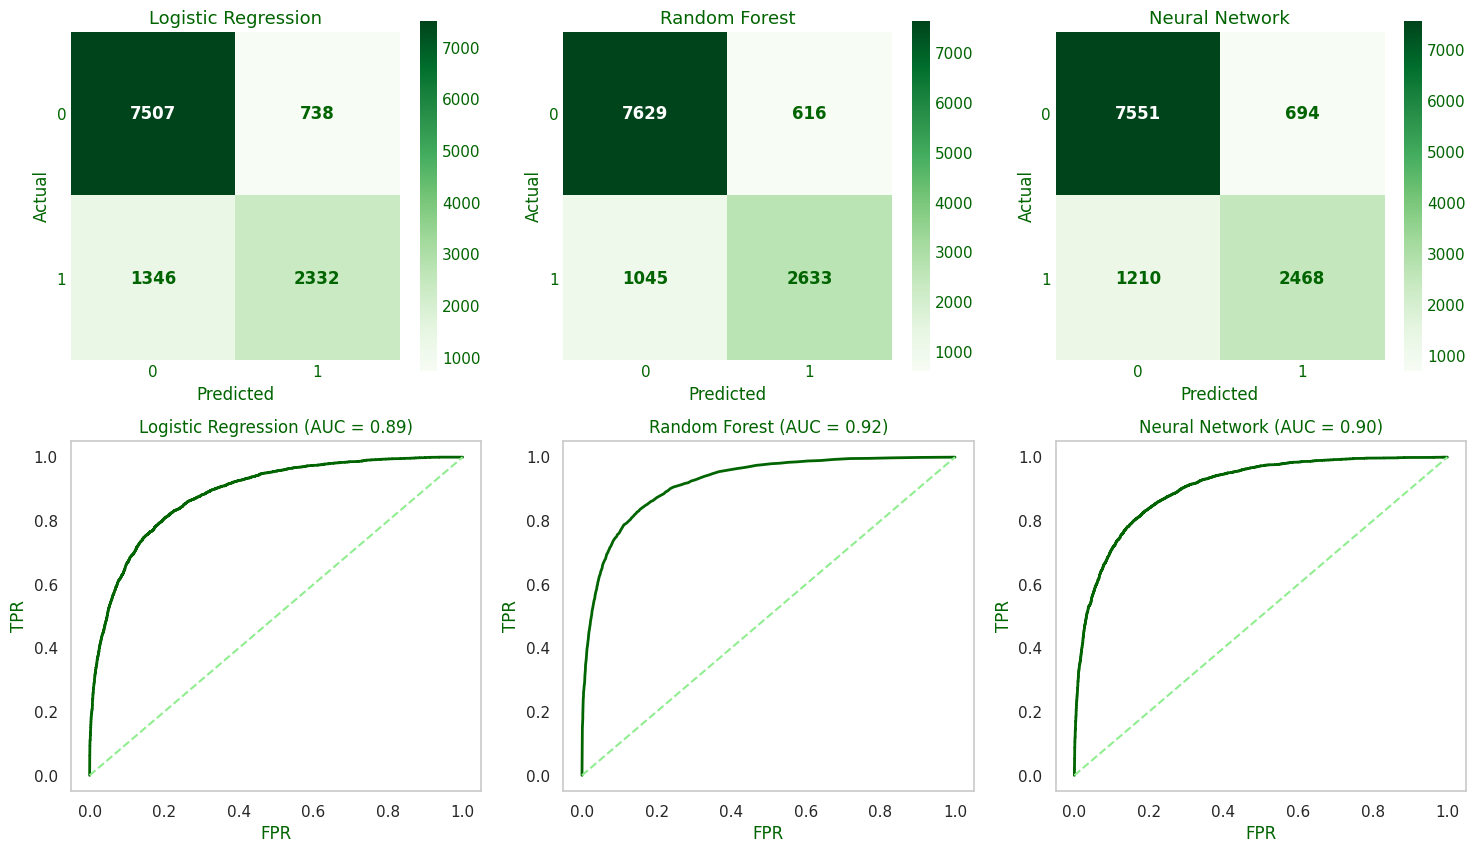

In [113]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Probabilities
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_nn = nn.predict_proba(X_test_scaled)[:, 1]

models = [
    ("Logistic Regression", y_pred_lr, y_prob_lr),
    ("Random Forest", y_pred_rf, y_prob_rf),
    ("Neural Network", y_pred_nn, y_prob_nn)
]

# Create subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

dark_green = "darkgreen"

for i, (name, y_pred, y_prob) in enumerate(models):

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(y_test, y_pred)
    ax = axes[0, i]

    im = ax.imshow(cm, cmap="Greens", interpolation='none')

    ax.set_title(name, color=dark_green, fontsize=13)
    ax.set_xlabel("Predicted", color=dark_green)
    ax.set_ylabel("Actual", color=dark_green)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['0', '1'], color=dark_green)
    ax.set_yticklabels(['0', '1'], color=dark_green)

    ax.grid(False)
    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    threshold = cm.max() / 2

    for x in range(cm.shape[0]):
        for y in range(cm.shape[1]):

            color = "white" if cm[x, y] > threshold else dark_green

            ax.text(
                y, x, cm[x, y],
                ha='center',
                va='center',
                color=color,
                fontweight='bold',
                fontsize=12
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(length=0, colors=dark_green)

    # =========================
    # ROC CURVE
    # =========================
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax = axes[1, i]

    ax.plot(fpr, tpr, color=dark_green, linewidth=2)

    ax.plot(
        [0, 1], [0, 1],
        linestyle='--',
        color='lightgreen'
    )

    ax.set_title(f"{name} (AUC = {roc_auc:.2f})",
                 color=dark_green)

    ax.set_xlabel("FPR", color=dark_green)
    ax.set_ylabel("TPR", color=dark_green)

    ax.grid(False)

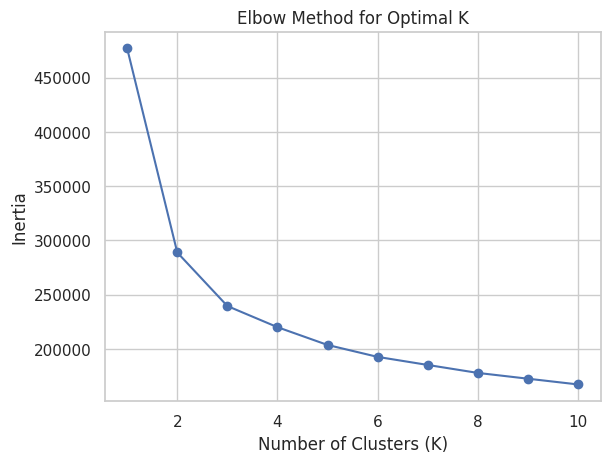

In [114]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for clustering (IMPORTANT)
cluster_features = [
    'study_hours_per_week',
    'sleep_hours',
    'social_media_hours',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'wellbeing_index',
    'brain_rot_index'
]

X_cluster = data[cluster_features]

# Optional: scale data (recommended)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


# =========================
# ELBOW METHOD
# =========================
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


# =========================
# PLOT
# =========================
plt.figure()
plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [115]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
data['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = data.groupby('cluster')[cluster_features].mean()

print(cluster_summary)

         study_hours_per_week  sleep_hours  social_media_hours  stress_level  \
cluster                                                                        
0                   20.438318     5.271420            4.315490      5.895213   
1                   25.904067     6.444691            2.619645      4.211001   
2                   21.996967     6.508572            2.547284      4.071486   

         anxiety_score  depression_score  wellbeing_index  brain_rot_index  
cluster                                                                     
0             5.946301          6.402194        49.903461        26.245686  
1             4.198179          4.287001        61.713767        14.354216  
2             4.043969          4.099152        62.739199        13.559679  


In [116]:
print(data['cluster'].value_counts().sort_index())

cluster
0    18081
1    21659
2    19871
Name: count, dtype: int64


In [117]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data['cluster_id'] = clusters

In [118]:
data.to_csv("Final Data.csv")